<a href="https://colab.research.google.com/github/Dhnxz/Graphs/blob/weather-data-analysis/weather_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [15]:
df = pd.read_csv("wheather_data.csv")

In [16]:
df.head()

,location,current,error
0,"{'name': 'Abohar', 'region': 'Punjab', 'countr...","{'last_updated_epoch': 1682924400, 'last_updat...",NaN
1,"{'name': 'Adoni', 'region': 'Andhra Pradesh', ...","{'last_updated_epoch': 1682924400, 'last_updat...",NaN
2,"{'name': 'Agartala', 'region': 'Tripura', 'cou...","{'last_updated_epoch': 1682924400, 'last_updat...",NaN
3,"{'name': 'Agra', 'region': 'Uttar Pradesh', 'c...","{'last_updated_epoch': 1682924400, 'last_updat...",NaN
4,"{'name': 'Ahmedabad', 'region': 'Gujarat', 'co...","{'last_updated_epoch': 1682924400, 'last_updat...",NaN


In [17]:
df = df.dropna(subset=['location', 'current'])

In [18]:
df['location'] = df['location'].apply(ast.literal_eval)

df['current'] = df['current'].apply(ast.literal_eval)

In [19]:
weather_df = pd.DataFrame()

weather_df['City'] = df['location'].apply(lambda x: x['name'])

weather_df['Temperature'] = df['current'].apply(lambda x: x['temp_c'])

weather_df['Humidity'] = df['current'].apply(lambda x: x['humidity'])

weather_df['Wind Speed'] = df['current'].apply(lambda x: x['wind_kph'])

weather_df['Pressure'] = df['current'].apply(lambda x: x['pressure_mb'])

weather_df['Condition'] = df['current'].apply(lambda x: x['condition']['text'])

In [20]:
weather_df.head()

,City,Temperature,Humidity,Wind Speed,Pressure,Condition
0,Abohar,28.2,45,12.6,1008.0,Partly cloudy
1,Adoni,32.6,46,3.6,1007.0,Partly cloudy
2,Agartala,32.0,56,6.8,1009.0,Mist
3,Agra,30.6,42,8.3,1007.0,Partly cloudy
4,Ahmedabad,31.0,41,9.0,1007.0,Overcast


In [21]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 0 to 120
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         117 non-null    object 
 1   Temperature  117 non-null    float64
 2   Humidity     117 non-null    int64  
 3   Wind Speed   117 non-null    float64
 4   Pressure     117 non-null    float64
 5   Condition    117 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 6.4+ KB


In [22]:
weather_df.describe()

,Temperature,Humidity,Wind Speed,Pressure
count,117.000000,117.000000,117.000000,117.000000
mean,28.715385,54.683761,10.413675,1008.299145
std,4.951587,17.855092,5.148349,2.533449
min,5.500000,25.000000,3.600000,989.000000
25%,27.000000,41.000000,6.500000,1007.000000
50%,30.000000,50.000000,9.400000,1008.000000
75%,31.800000,66.000000,14.800000,1009.000000
max,35.500000,93.000000,24.800000,1019.000000


**Temperature Bar Chart**

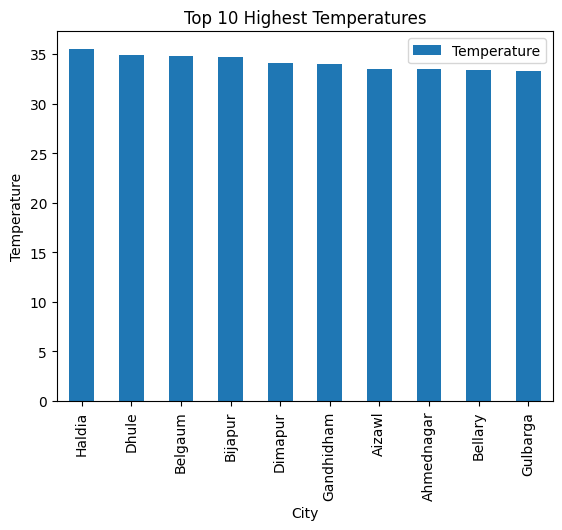

In [23]:
weather_df.sort_values('Temperature', ascending=False).head(10).plot(
    x='City',
    y='Temperature',
    kind='bar'
)

plt.title("Top 10 Highest Temperatures")

plt.ylabel("Temperature")

plt.show()

**Humidity Histogram**

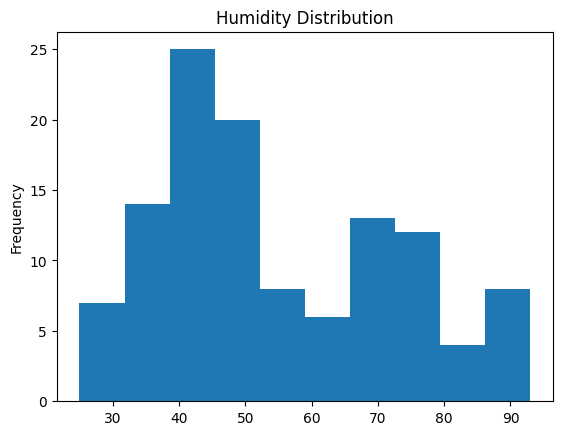

In [24]:
weather_df['Humidity'].plot(kind='hist')

plt.title("Humidity Distribution")

plt.show()

**Wind Speed Line Chart**

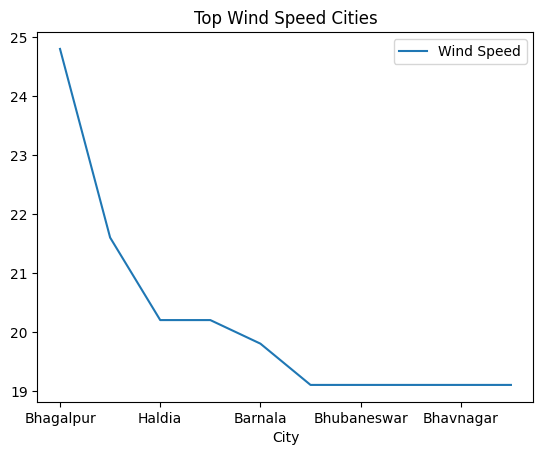

In [25]:
weather_df.sort_values('Wind Speed', ascending=False).head(10).plot(
    x='City',
    y='Wind Speed',
    kind='line'
)

plt.title("Top Wind Speed Cities")

plt.show()

**Weather Conditions Count Plot**

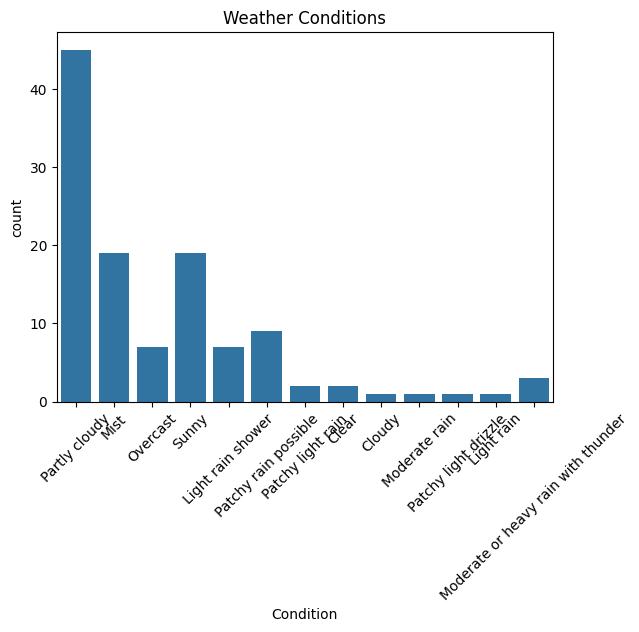

In [26]:
sns.countplot(x='Condition', data=weather_df)

plt.xticks(rotation=45)

plt.title("Weather Conditions")

plt.show()

**Scatter Plot**

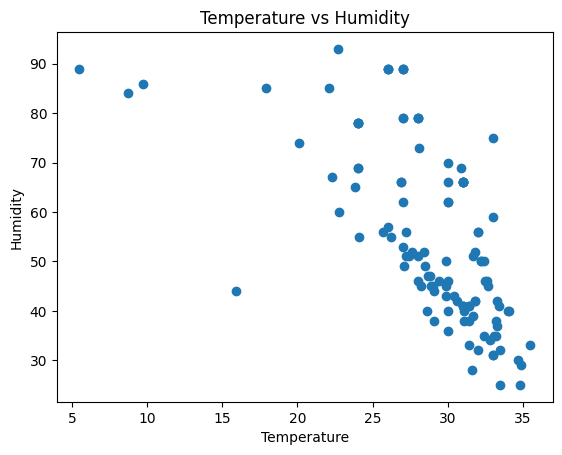

In [27]:
plt.scatter(
    weather_df['Temperature'],
    weather_df['Humidity']
)

plt.xlabel("Temperature")

plt.ylabel("Humidity")

plt.title("Temperature vs Humidity")

plt.show()

**Correlation Heatmap**

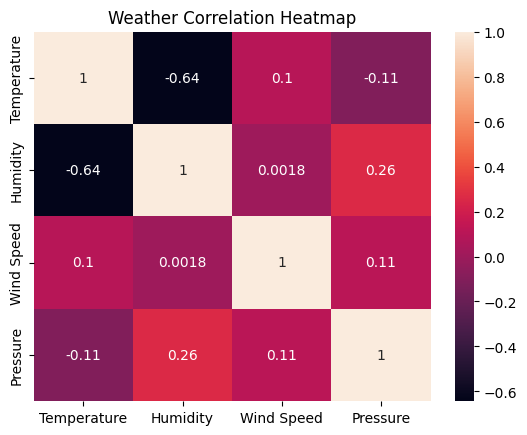

In [28]:
sns.heatmap(
    weather_df[['Temperature', 'Humidity', 'Wind Speed', 'Pressure']].corr(),
    annot=True
)

plt.title("Weather Correlation Heatmap")

plt.show()